In [28]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image
import random

## state_schema

In [34]:
class AgentState(TypedDict):
    name: str
    random_values: List[int]
    iterator: int

In [35]:
random.randint(0, 10)

5

## Nodes

In [36]:
def greeting_node(state: AgentState) -> AgentState:
    """This node will greet user"""

    print(f"Welcome, {state['name']}")
    state['iterator'] = 0

    return state

def random_node(state: AgentState) -> AgentState:
    """Generates a random from 0 to 10"""

    state['random_values'].append(random.randint(0, 10))
    state['iterator'] += 1

    return state

def should_continue(state: AgentState):
    """Function to decide what to do next"""

    if state['iterator'] < 5:

        return "loop"
    else:

        return "exit"

## Create Graph

In [37]:
graph = StateGraph(AgentState)


# add nodes

graph.add_node("greeting_node", greeting_node)
graph.add_node("random_node", random_node)
# graph.add_node("should_continue", should_continue)


graph.add_edge(START, "greeting_node")
graph.add_edge("greeting_node", "random_node")

graph.add_conditional_edges(
    "random_node",
    should_continue,

    {

        "loop": "random_node",
        "exit": END
    }
)


app = graph.compile()

## Draw graph

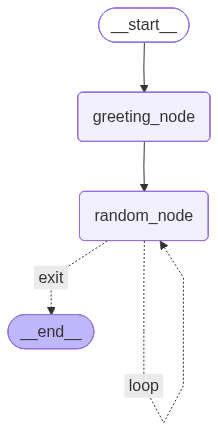

In [38]:
display(Image(app.get_graph().draw_mermaid_png()))

## Invoke

In [58]:
response = app.invoke(AgentState(name="Bakar", random_values=[], iterator=2))

Welcome, Bakar


In [59]:
response['random_values']

[9, 9, 9, 7, 6]